# Here we process blocks 1 and 2 to get static and atmospheric information

In [1]:
from irrigator.config import load_region_config, load_parcel_config
from irrigator.static_layers import get_soil_profile, get_terrain_params
from irrigator.static_layers.terrain import get_era5_elevation
from irrigator.atmospheric.era5_processor import process_era5_to_daily, save_daily, load_daily
from irrigator.atmospheric.forcing import extract_parcel_forcing
from irrigator.ingestion.cds_client import open_era5_land
import os

In [2]:
PARENT = str(os.path.dirname(os.getcwd()))

cfg = load_region_config(PARENT + "/configs/dordogne.yaml")
parcel = load_parcel_config(PARENT + "/configs/parcels/example.yaml")


In [3]:

# Block 1: static layers
soil = get_soil_profile(cfg, parcel)
terrain = get_terrain_params(cfg, parcel)
terrain.era5_elevation_m = get_era5_elevation(cfg, parcel)


In [4]:

# Block 2: atmospheric forcing
# First time: process hourly → daily (slow, do once)
era5_hourly = open_era5_land(cfg)
era5_daily = process_era5_to_daily(era5_hourly)
save_daily(era5_daily, cfg)


/home/mbaldacchino/code/IrriGator/src/irrigator/atmospheric/era5_processor.py:153: SerializationWarning: variable expver has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  ds.to_netcdf(out_path)


In [6]:
# After that: just load
era5_daily = load_daily(cfg)

# Extract forcing at parcel (with downscaling)
forcing = extract_parcel_forcing(era5_daily, parcel, terrain)
df = forcing.to_dataframe()
df.head()


,t_min,t_max,t_mean,dewpoint,wind_speed_2m,pressure_kpa,rs_mj,precip_mm
date,,,,,,,,
1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,2.135998,4.559430
2000-01-01,6.782787,9.008434,7.715648,7.528179,0.488206,101.705147,1.232845,0.937238
2000-01-02,6.870861,8.887310,7.777141,6.338787,0.737153,101.820229,3.515391,0.030760
2000-01-03,3.675426,9.947338,6.284404,4.645946,1.256277,101.708313,6.546174,0.015819
2000-01-04,3.006115,10.500621,6.644542,4.914043,1.500889,101.534447,6.008706,0.057811


# Block 3 : Compute 

27.220479398965836
0.0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
2002-04-20
0
20

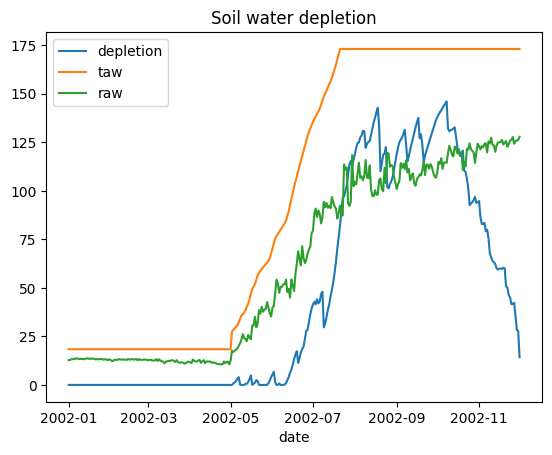

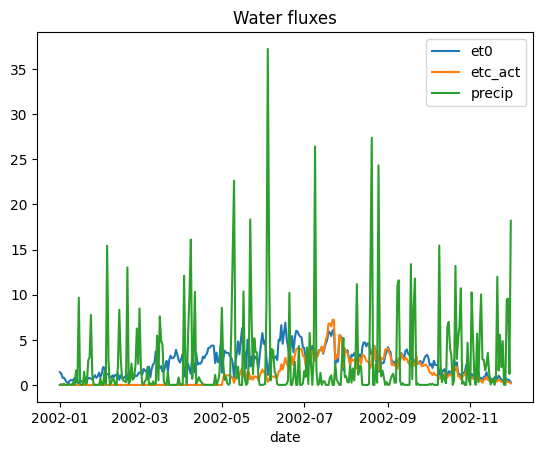

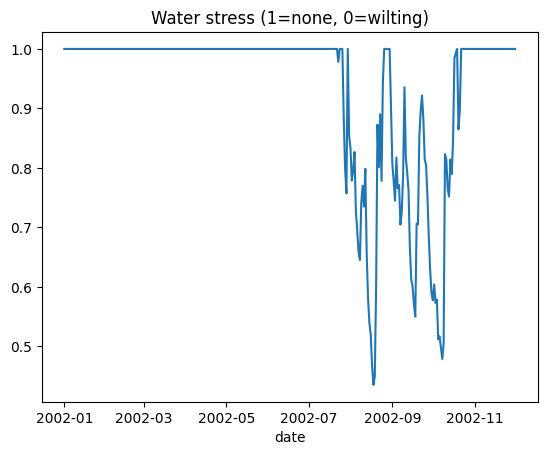

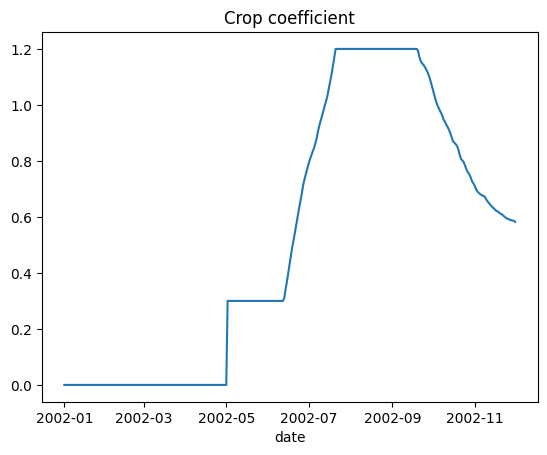

In [7]:
from irrigator.crop.phenology import CropParams
from irrigator.water_balance.bucket_model import run_simulation, states_to_dataframe
import matplotlib.pyplot as plt

# Load crop params from your existing config files
crop_params = CropParams.from_config(parcel.crop, crop_params_path=PARENT + "/configs/crop_parameters.yaml")

# Run the full simulation (no irrigation = rainfed scenario)
states = run_simulation(forcing.slice(start="2002-01-01", end="2002-12-01"), parcel, terrain, soil, crop_params)

# Convert to DataFrame for plotting
df = states_to_dataframe(states)

# Plot key variables
df[["depletion", "taw", "raw"]].plot(title="Soil water depletion")
plt.show()
df[["et0", "etc_act", "precip"]].plot(title="Water fluxes")
plt.show()
df["stress_coeff"].plot(title="Water stress (1=none, 0=wilting)")
plt.show()
df["kc"].plot(title="Crop coefficient")
plt.show()


In [ ]:
# IRRIGATED CASE :


irrigation = {
    date(2022, 7, 10): 35,  # 35 mm on July 10
    date(2022, 7, 25): 30,  # 30 mm on July 25
}
states = run_simulation(forcing, parcel, terrain, soil, crop_params, irrigation_schedule=irrigation)

In [6]:
df["gdd"].plot()

NameError: name 'df' is not defined

In [8]:
import pandas as pd
df.index = pd.to_datetime(df.index)
df["gdd"].diff().resample("M").sum()


/tmp/ipykernel_2440972/2406530271.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df["gdd"].diff().resample("M").sum()


date
2002-01-31      0.000000
2002-02-28      0.000000
2002-03-31      0.000000
2002-04-30     57.484367
2002-05-31    157.511068
2002-06-30    294.819698
2002-07-31    308.600165
2002-08-31    304.944531
2002-09-30    236.491277
2002-10-31    166.253309
2002-11-30     62.669851
2002-12-31      1.848882
Freq: ME, Name: gdd, dtype: float64